In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT

Welcome to JupyROOT 6.30/04


In [2]:
# Asegurarse que AUGEROFFLINEROOT está definido
AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError("AUGEROFFLINEROOT no definido. Hacé 'source this-auger-offline.sh' primero.")

# -----------------------------
# 1️⃣ Cargar librerías Offline
# -----------------------------
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    ROOT.gSystem.Load(os.path.join(AugerOfflineRoot, "lib", lib))


In [3]:
# -----------------------------
# 2️⃣ Funciones auxiliares
# -----------------------------
def getCounterList(sevent, mevent):
    cList = []
    stationVector = sevent.GetStationVector()
    for station in stationVector:
        stationId = station.GetId()
        counterId = int("10" + str(stationId))
        if mevent.HasCounter(counterId):
            cList.append(mevent.GetCounter(counterId))
    return cList

def getModuleList(counter, sim=True):
    possibleModules = range(0,6) if sim else range(100,116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

# -----------------------------
# 3️⃣ Función principal
# -----------------------------
def readADST_to_df(fname):
    # Preparar ADST
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles: 
        files.push_back(datfile)

    # Crear RecEventFile y RecEvent
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        nModulos = 0
        for counter in counterList:
            if counter.IsRejected() or counter.IsSaturated(): continue
            modulesList = getModuleList(counter)
            for mod in modulesList:
                if mod.IsRejected() or mod.IsSaturated(): continue
                nModulos += 1

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC,
            "primary": primary, "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "nModulos": nModulos,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1]
        })

    df = pd.DataFrame(data)
    return df

   logE_MC  theta_MC      phi_MC primary   logE_REC  theta_REC     phi_REC  \
0     18.5      15.0  279.238856       p  18.330779  13.922803  279.403181   
1     18.5      15.0  135.866637       p  18.382202  14.986750  135.512647   
2     18.5      15.0  177.855895       p  18.374912  14.827261  179.512504   
3     18.5      15.0   44.160211       p  18.100016  15.863223   44.540219   
4     18.5      15.0    3.601776       p  18.393361  15.121237    3.474073   

   nModulos      coreUTM_X     coreUTM_Y    coreSite_X    coreSite_Y  
0        45  451036.801590  6.114361e+06 -26198.037100  15233.158806  
1        49  450623.723298  6.114410e+06 -26611.242338  15282.865118  
2        54  451081.529317  6.113464e+06 -26155.535244  14335.504279  
3        28  451245.473213  6.114092e+06 -25989.916903  14962.747386  
4        56  451807.500423  6.113885e+06 -25428.069633  14754.333795  


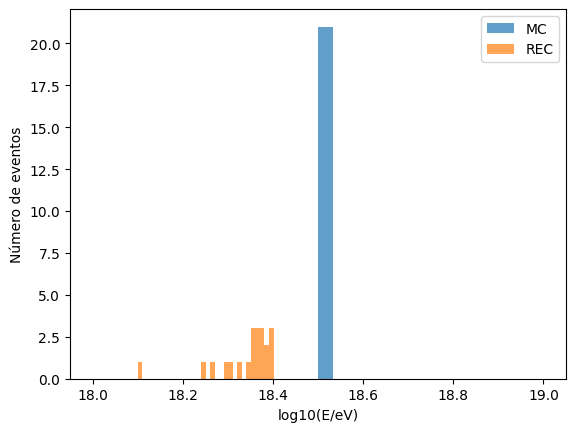

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root
Warning in <TClass::Init>: no dictionary for class RdBeamQuants is available
Warning in <TClass::Init>: no dictionary for class RdBeamPeak is available
Warning in <TClass::Init>: no dictionary for class SimRdPulse is available
Warning in <TStreamerInfo::BuildOld>: Cannot convert Detector::fTelPointingIds from type: map<int,EyePointingIdMap> to type: map<int,map<int,TString> >, skip element
Warning in <TStreamerInfo::BuildOld>: Cannot convert TFormula::fParams from type: Double_t* to type: map<TString,int,TFormulaParamOrder>, skip element
Warning in <TStreamerInfo::BuildOld>: Cannot convert TFormula::fLinearParts from type: TObjArray to type: vector<TObject*>, skip element
Warning in <TStreamerInfo::Compile>: Counter fNpar should not be skipped from class TFormula
Warning in <TStreamerInfo::Compile>: Counter fNoper should not be skipped from class TFormula
Warning in <TStreamerInfo::Compile>: Counter fNconst should not be skipp

In [4]:
# -----------------------------
# Ejecutar
# -----------------------------
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
df = readADST_to_df(fname)
print(df.head())

# Guardar en .npz
np.savez_compressed("ADST_simulation.npz", df=df.to_dict("list"))

# -----------------------------
# Plot rápido
# -----------------------------

plt.hist(df["logE_MC"], bins=30, alpha=0.7, label="MC")
plt.hist(df["logE_REC"], bins=30, alpha=0.7, label="REC")
plt.xlabel("log10(E/eV)")
plt.ylabel("Número de eventos")
plt.legend()
plt.show()

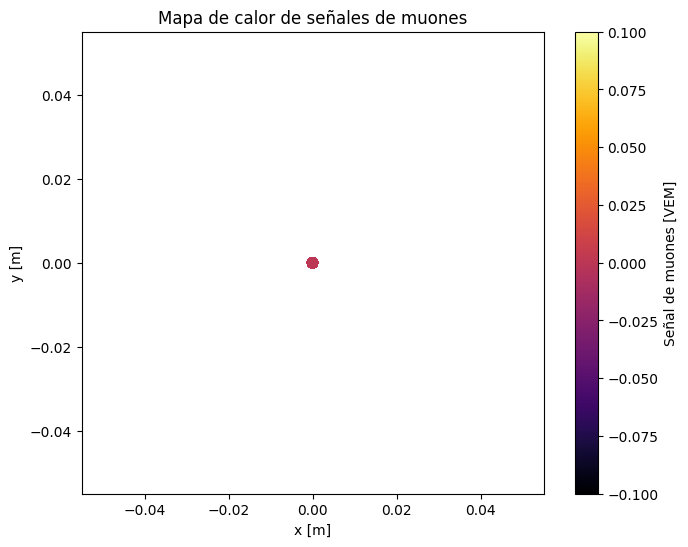

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT

# Asegurarse que AUGEROFFLINEROOT está definido
AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError("AUGEROFFLINEROOT no definido. Hacé 'source this-auger-offline.sh' primero.")

# -----------------------------
# 1️⃣ Cargar librerías Offline
# -----------------------------
lib_dir = os.path.join(AugerOfflineRoot, "lib")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    full_path = os.path.join(lib_dir, lib)
    if os.path.exists(full_path):
        ROOT.gSystem.Load(full_path)

# -----------------------------
# 2️⃣ Función principal
# -----------------------------
def readMD_heatmap(fname):
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []
    station_pos = {}

    # Loop sobre eventos
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        sEvent = event.GetSDEvent()
        for sdStation in sEvent.GetStationVector():
            sid = sdStation.GetId()
            # Solo procesar estaciones no rechazadas
            if sdStation.IsRejected():
                continue

            # Guardar posición la primera vez
            if sid not in station_pos:
                try:
                    pos = sdStation.GetCoreSiteCS()  # lista [x, y, z]
                    station_pos[sid] = pos
                except:
                    # Si no hay GetCoreSiteCS(), usar 0,0 como fallback
                    station_pos[sid] = [0,0,0]
            x, y, z = station_pos[sid]

            # Señales
            total_signal = sdStation.GetTotalSignal()
            muon_signal = sdStation.GetMuonComponent()

            data.append({
                "station_id": sid,
                "x": x,
                "y": y,
                "total_signal": total_signal,
                "muon_signal": muon_signal
            })

    df = pd.DataFrame(data)
    return df

# -----------------------------
# 3️⃣ Ejecutar
# -----------------------------
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
df_md = readMD_heatmap(fname)

# Guardar en .npz
np.savez("md_signals.npz",
         x=df_md['x'].values,
         y=df_md['y'].values,
         total_signal=df_md['total_signal'].values,
         muon_signal=df_md['muon_signal'].values,
         station_id=df_md['station_id'].values)

# -----------------------------
# 4️⃣ Mapa de calor
# -----------------------------
plt.figure(figsize=(8,6))
sc = plt.scatter(df_md['x'], df_md['y'], c=df_md['muon_signal'], cmap='inferno', s=50)
plt.colorbar(sc, label='Señal de muones [VEM]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de calor de señales de muones')
plt.gca().set_aspect('equal', 'box')
plt.show()

Número de estaciones en el evento 0: 22
Estación 4007: x=0.0, y=0.0, muones=0.00
Estación 4001: x=0.0, y=0.0, muones=0.00
Estación 4006: x=0.0, y=0.0, muones=0.00
Estación 4002: x=0.0, y=0.0, muones=0.00
Estación 4017: x=0.0, y=0.0, muones=0.00
Estación 4018: x=0.0, y=0.0, muones=0.00
Estación 4019: x=0.0, y=0.0, muones=0.00
Estación 4005: x=0.0, y=0.0, muones=0.00
Estación 4016: x=0.0, y=0.0, muones=0.00
Estación 4003: x=0.0, y=0.0, muones=0.00
Estación 4004: x=0.0, y=0.0, muones=0.00
Estación 4015: x=0.0, y=0.0, muones=0.00
Estación 4036: x=0.0, y=0.0, muones=0.00
Estación 4008: x=0.0, y=0.0, muones=0.00
Estación 4009: x=0.0, y=0.0, muones=0.00
Estación 4034: x=0.0, y=0.0, muones=0.00
Estación 4010: x=0.0, y=0.0, muones=0.00
Estación 4014: x=0.0, y=0.0, muones=0.00
Estación 4035: x=0.0, y=0.0, muones=0.00
Estación 4031: x=0.0, y=0.0, muones=0.00
Estación 4011: x=0.0, y=0.0, muones=0.00
Estación 4013: x=0.0, y=0.0, muones=0.00


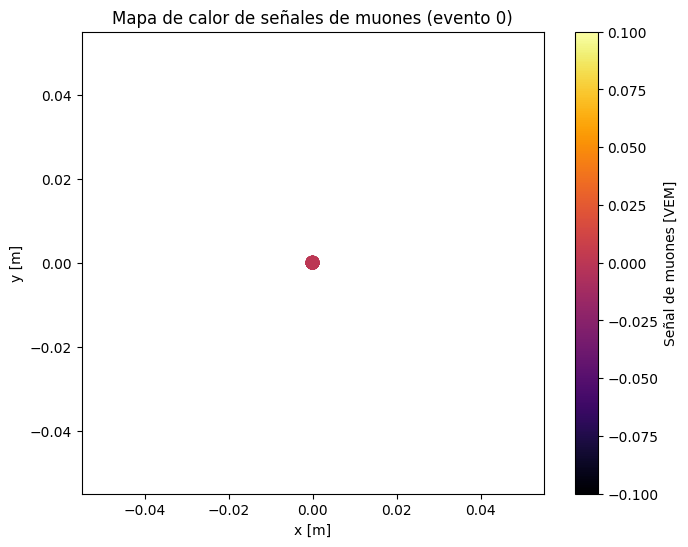

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


In [18]:
def readMD_heatmap_event(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.ReadDetectorGeometry(ROOT.DetectorGeometry())  # cargar geometría
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        print(f"Número de estaciones en el evento {event_index}: {len(stations)}")
        
        data = []
        for sdStation in stations:
            sid = sdStation.GetId()
            muon = sdStation.GetMuonComponent()  # señal de muones
            
            try:
                pos = sdStation.GetCoreSiteCS()  # lista [x, y, z]
            except:
                pos = [0,0,0]
            
            x, y = pos[0], pos[1]
            print(f"Estación {sid}: x={x:.1f}, y={y:.1f}, muones={muon:.2f}")
            
            data.append({
                "station_id": sid,
                "x": x,
                "y": y,
                "muon_signal": muon
            })
        
        df = pd.DataFrame(data)
        return df

# -----------------------------
# Ejecutar
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
df_md = readMD_heatmap_event(fname, event_index=0)

# -----------------------------
# Scatter plot (solo superficie)
plt.figure(figsize=(8,6))
sc = plt.scatter(df_md['x'], df_md['y'], c=df_md['muon_signal'], cmap='inferno', s=80)
plt.colorbar(sc, label='Señal de muones [VEM]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de calor de señales de muones (evento 0)')
plt.gca().set_aspect('equal', 'box')
plt.show()


In [17]:
def readMD_heatmap_event(fname, event_index=0):
    # Abrir archivo
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        print(f"Número de estaciones en el evento {event_index}: {len(stations)}")
        
        data = []
        for sdStation in stations:
            sid = sdStation.GetId()
            muon = sdStation.GetMuonComponent()
            
            sc = sdStation.GetScintillator()
            # Promedio de posiciones de los 3 módulos
            xs = [sc.GetModule(i).GetPosition().X() for i in range(3)]
            ys = [sc.GetModule(i).GetPosition().Y() for i in range(3)]
            x_avg = sum(xs)/3
            y_avg = sum(ys)/3
            
            print(f"Estación {sid}: x={x_avg:.1f}, y={y_avg:.1f}, muones={muon:.2f}")
            
            data.append({
                "station_id": sid,
                "x": x_avg,
                "y": y_avg,
                "muon_signal": muon
            })
        
        df = pd.DataFrame(data)
        return df

# -----------------------------
# Ejecutar
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
df_md = readMD_heatmap_event(fname, event_index=0)

# -----------------------------
# Scatter plot (solo superficie)
plt.figure(figsize=(8,6))
sc = plt.scatter(df_md['x'], df_md['y'], c=df_md['muon_signal'], cmap='inferno', s=80)
plt.colorbar(sc, label='Señal de muones [VEM]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de calor de señales de muones (evento 0)')
plt.gca().set_aspect('equal', 'box')
plt.show()


Número de estaciones en el evento 0: 22


AttributeError: 'SdRecScintillator' object has no attribute 'GetModule'

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


In [19]:
def print_sdstation_methods(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        print(f"Número de estaciones en el evento {event_index}: {len(stations)}")
        
        for sdStation in stations:
            print(f"\nEstación ID={sdStation.GetId()}")
            # Listar todos los atributos y métodos
            for attr in dir(sdStation):
                if not attr.startswith("__"):
                    print(attr)
        break  # solo el primer evento

# Ejecutar
print_sdstation_methods("ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root")


Número de estaciones en el evento 0: 22

Estación ID=4007
AbstractMethod
AddPMTTraces
AppendPad
Browse
CheckedHash
Class
ClassName
Class_Name
Class_Version
Clear
Clone
Compare
Copy
DeclFileLine
DeclFileName
Delete
Dictionary
DistancetoPrimitive
Draw
DrawClass
DrawClone
Dump
Error
Execute
ExecuteEvent
Fatal
FindObject
GetAssymCorrRiseTime
GetAssymCorrRiseTimeError
GetAssymCorrRiseTimeErrorKG
GetAssymCorrRiseTimeKG
GetAzimuthSP
GetBaseline
GetBaselineLG
GetBaselineLGRMS
GetBaselineRMS
GetBottomUpResidual
GetCalibrationVersion
GetCharge
GetChargeError
GetCorrRiseTime
GetCorrRiseTimeRMS
GetCurvatureTimeResidual
GetDrawOption
GetDtorOnly
GetDynodeAnodeRatio
GetElectronSignal
GetFallTime
GetFallTimeRMS
GetHighGainTrace
GetIconName
GetId
GetLDFResidual
GetLowGainTrace
GetMPDDepth
GetMPDDepthError
GetMPDSignal
GetMPDSignalError
GetMuonComponent
GetMuonSignal
GetName
GetObjectInfo
GetObjectStat
GetOption
GetPLDTimeOffset
GetPLDVersion
GetPLDVersionAsInt
GetPMTTraces
GetPeak
GetPeakError
GetPhot

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


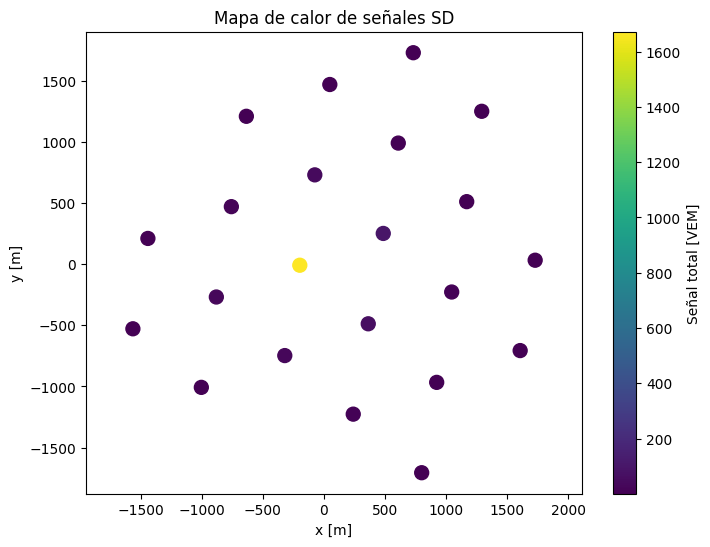

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


In [20]:
def readMD_heatmap_event(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        
        xs, ys, signals = [], [], []
        
        for sdStation in stations:
            r = sdStation.GetSPDistance()
            phi = sdStation.GetAzimuthSP()  # en radianes
            x = r * np.cos(phi)
            y = r * np.sin(phi)
            xs.append(x)
            ys.append(y)
            signals.append(sdStation.GetTotalSignal())
        return np.array(xs), np.array(ys), np.array(signals)

# Ejecutar
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
xs, ys, signals = readMD_heatmap_event(fname, event_index=0)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(xs, ys, c=signals, s=100, cmap='viridis')
plt.colorbar(label='Señal total [VEM]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de calor de señales SD')
plt.axis('equal')
plt.show()

Número de estaciones en el evento 0: 22
Estación ID=4007
  --> No tiene UMD, saltando
Estación ID=4001
  --> No tiene UMD, saltando
Estación ID=4006
  --> No tiene UMD, saltando
Estación ID=4002
  --> No tiene UMD, saltando
Estación ID=4017
  --> No tiene UMD, saltando
Estación ID=4018
  --> No tiene UMD, saltando
Estación ID=4019
  --> No tiene UMD, saltando
Estación ID=4005
  --> No tiene UMD, saltando
Estación ID=4016
  --> No tiene UMD, saltando
Estación ID=4003
  --> No tiene UMD, saltando
Estación ID=4004
  --> No tiene UMD, saltando
Estación ID=4015
  --> No tiene UMD, saltando
Estación ID=4036
  --> No tiene UMD, saltando
Estación ID=4008
  --> No tiene UMD, saltando
Estación ID=4009
  --> No tiene UMD, saltando
Estación ID=4034
  --> No tiene UMD, saltando
Estación ID=4010
  --> No tiene UMD, saltando
Estación ID=4014
  --> No tiene UMD, saltando
Estación ID=4035
  --> No tiene UMD, saltando
Estación ID=4031
  --> No tiene UMD, saltando
Estación ID=4011
  --> No tiene UMD, sal

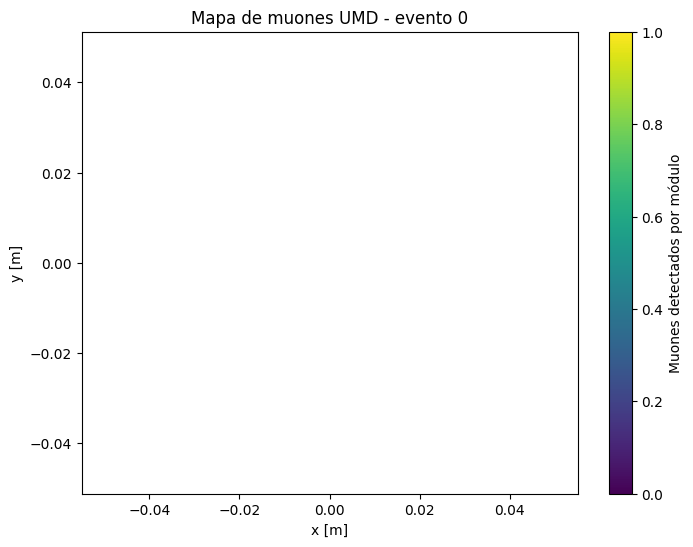

  input file ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root


In [26]:
def readMD_heatmap_event(fname, event_index=0):
    files = ROOT.std.vector('string')()
    files.push_back(fname)
    
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    file1.SetBuffers(event)
    
    i_event = -1
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        i_event += 1
        if i_event != event_index:
            continue
        
        sEvent = event.GetSDEvent()
        stations = sEvent.GetStationVector()
        print(f"Número de estaciones en el evento {event_index}: {stations.size()}")
        
        xs, ys, muon_signals = [], [], []
        station_ids, module_ids = [], []

        for sdStation in stations:
            print(f"Estación ID={sdStation.GetId()}")
            
            if not sdStation.HasScintillator():
                print("  --> No tiene UMD, saltando")
                continue  # solo estaciones UMD
            
            sc = sdStation.GetScintillator()
            n_modules = 3  # típicamente 3 módulos por estación UMD
            pos = sdStation.GetPosition()
            x = pos.X()
            y = pos.Y()
            print(f"  Posición estación: x={x}, y={y}")

            for i in range(n_modules):
                try:
                    muones = sc.GetMuonSignal(i)
                except Exception as e:
                    print(f"    Error al leer módulo {i}: {e}")
                    muones = 0
                print(f"    Módulo {i} detectó {muones} muones")
                
                xs.append(x)
                ys.append(y)
                muon_signals.append(muones)
                station_ids.append(sdStation.GetId())
                module_ids.append(i)
        
        print("Fin de lectura de evento.")
        return {
            'x': np.array(xs),
            'y': np.array(ys),
            'muons': np.array(muon_signals),
            'station_id': np.array(station_ids),
            'module_id': np.array(module_ids)
        }

# Ejecutar
fname = "ADST_SUPERAMIGA_230cm_Proton_e1850_t15_v2.root"
data = readMD_heatmap_event(fname, event_index=0)

plt.figure(figsize=(8,6))
sc = plt.scatter(data['x'], data['y'], c=data['muons'], s=200, cmap='viridis', edgecolor='k')
plt.colorbar(sc, label='Muones detectados por módulo')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa de muones UMD - evento 0')
plt.axis('equal')
plt.show()
